# 1. INSTALL & IMPORT

In [11]:
#!pip install sastrawi transformers torch scikit-learn seaborn

import pandas as pd
import numpy as np
import re
import torch
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 2. LOAD DATA

In [2]:
df = pd.read_csv('/content/hasil_auto_labeling(3).csv')
df = df[['text','label']].dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11199 entries, 0 to 11198
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    11199 non-null  object
 1   label   11199 non-null  object
dtypes: object(2)
memory usage: 175.1+ KB


**CEK DISTRIBUSI LABEL**

In [3]:
print(df['label'].value_counts())

label
netral        5758
kritik        3904
pertanyaan    1232
saran          205
pujian         100
Name: count, dtype: int64


# 3. PREPROCESSING

**HAPUS DUPLIKAT**

In [3]:
df.drop_duplicates(subset ="text", keep = 'first', inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10816 entries, 0 to 11198
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10816 non-null  object
 1   label   10816 non-null  object
dtypes: object(2)
memory usage: 253.5+ KB


**BERSIHKAN TEKS**

In [4]:
def clean_text(text):
    text = text.lower()

    # hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # hapus angka (opsional)
    text = re.sub(r'\d+', '', text)

    # hapus karakter aneh (TAPI JANGAN HAPUS SEMUA)
    text = re.sub(r'[^\w\s!?]', '', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean'] = df['text'].astype(str).apply(clean_text)

# 4. OVERSAMPLING

In [5]:
synonym_dict = {
    "bagus": ["baik", "mantap", "keren"],
    "jelek": ["buruk", "parah"],
    "cepat": ["kilat", "lekas"],
    "lambat": ["lama", "lelet"]
}

def augment_text(text):
    words = text.split()

    # synonym
    new_words = []
    for w in words:
        if w in synonym_dict and random.random() < 0.3:
            new_words.append(random.choice(synonym_dict[w]))
        else:
            new_words.append(w)

    # typo ringan
    if random.random() < 0.2 and len(new_words) > 3:
        i = random.randint(0, len(new_words)-1)
        word = new_words[i]
        if len(word) > 3:
            j = random.randint(0, len(word)-2)
            word = word[:j] + word[j+1] + word[j] + word[j+2:]
            new_words[i] = word

    return " ".join(new_words)

print("SEBELUM BALANCING:")
print(df['label'].value_counts())

target_size = df['label'].value_counts().max()

df_balanced = []

for label in df['label'].unique():
    subset = df[df['label'] == label]

    if len(subset) < target_size:
        # oversample + augment
        extra = subset.sample(target_size - len(subset), replace=True)
        extra['clean'] = extra['clean'].apply(augment_text)
        subset = pd.concat([subset, extra])

    df_balanced.append(subset)

df = pd.concat(df_balanced)

print("\nSETELAH BALANCING:")
print(df['label'].value_counts())


SEBELUM BALANCING:
label
netral        5539
kritik        3809
pertanyaan    1195
saran          194
pujian          79
Name: count, dtype: int64

SETELAH BALANCING:
label
saran         5539
kritik        5539
pujian        5539
netral        5539
pertanyaan    5539
Name: count, dtype: int64


# 5. LABEL ENCODING

In [6]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print("\nLabel mapping:")
print(le.classes_)


Label mapping:
['kritik' 'netral' 'pertanyaan' 'pujian' 'saran']


# 6. SPLIT

In [8]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['clean'], df['label_enc'],
    test_size=0.2, stratify=df['label_enc'], random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5, stratify=temp_labels, random_state=42)

# 7. CLASS WEIGHT

In [9]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))

print("\nClass weights:", class_weights)


Class weights: {0: np.float64(1.0000451365380276), 1: np.float64(0.9998194945848375), 2: np.float64(1.0000451365380276), 3: np.float64(1.0000451365380276), 4: np.float64(1.0000451365380276)}


# 8. TOKENIZER (CNN & BiLSTM)

**TOKENIZER MANUAL (KERAS)**

In [12]:
max_words = 30000
max_len = 120

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>",
    filters=''  #
)

tokenizer.fit_on_texts(train_texts)

train_seq = tokenizer.texts_to_sequences(train_texts)
val_seq   = tokenizer.texts_to_sequences(val_texts)
test_seq  = tokenizer.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(
    train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    val_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

y_train = train_labels
y_val   = val_labels
y_test  = test_labels

print("Train:", X_train_pad.shape)
print("Val  :", X_val_pad.shape)
print("Test :", X_test_pad.shape)

Train: (22156, 120)
Val  : (2769, 120)
Test : (2770, 120)


# 9. EARLY STOPPING

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 10. MODEL RNN

In [24]:
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import tensorflow as tf

# ================================
# CALLBACKS
# ================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# ================================
# MODEL RNN
# ================================
rnn_model = tf.keras.Sequential([

    Embedding(30000, 64, input_length=120),

    SpatialDropout1D(0.2),

    SimpleRNN(64, return_sequences=True),
    Dropout(0.3),

    SimpleRNN(32),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(5, activation='softmax')
])

# ================================
# COMPILE
# ================================
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # 🔥 TURUNKAN
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ================================
# TRAINING
# ================================
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ================================
# PREDICT
# ================================
rnn_pred = np.argmax(rnn_model.predict(X_test_pad), axis=1)

# ================================
# EVALUASI
# ================================
rnn_acc = accuracy_score(y_test, rnn_pred)

print("\n=== RNN FIXED ===")
print("Accuracy:", rnn_acc)
print(classification_report(y_test, rnn_pred, target_names=le.classes_))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


347/347 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.2109 - loss: 2.0160 - val_accuracy: 0.3124 - val_loss: 1.4994 - learning_rate: 3.0000e-04
Epoch 2/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.3961 - loss: 1.4360 - val_accuracy: 0.6277 - val_loss: 0.8239 - learning_rate: 3.0000e-04
Epoch 3/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6148 - loss: 0.8838 - val_accuracy: 0.7320 - val_loss: 0.5900 - learning_rate: 3.0000e-04
Epoch 4/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7436 - loss: 0.6025 - val_accuracy: 0.8007 - val_loss: 0.4372 - learning_rate: 3.0000e-04
Epoch 5/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8310 - loss: 0.4219 - val_accuracy: 0.8458 - val_loss: 0.3422 - learning_rate: 3.0000e-04
Epoch 6/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8895 - loss: 0.2988 - val_accuracy: 0.8397 - val_loss: 0.4019 - learning_rate: 3.0000e-04
Epoch 7/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9

# 11. MODEL BiLSTM

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# ================================
# CALLBACKS
# ================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# ================================
# MODEL BiLSTM
# ================================
bilstm_model = tf.keras.Sequential([

    Embedding(30000, 128, input_length=120),

    SpatialDropout1D(0.3),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),

    Bidirectional(LSTM(64)),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(5, activation='softmax')
])

# ================================
# COMPILE
# ================================
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),  # 🔥 lebih stabil
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ================================
# TRAINING
# ================================
history_bilstm = bilstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ================================
# PREDICTION
# ================================
bilstm_pred = np.argmax(bilstm_model.predict(X_test_pad), axis=1)

# ================================
# EVALUASI
# ================================
bilstm_acc = accuracy_score(y_test, bilstm_pred)

print("\n=== BiLSTM ===")
print("Accuracy:", bilstm_acc)
print(classification_report(y_test, bilstm_pred, target_names=le.classes_))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


347/347 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.5303 - loss: 1.1029 - val_accuracy: 0.7862 - val_loss: 1.0347 - learning_rate: 2.0000e-04
Epoch 2/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8037 - loss: 0.5076 - val_accuracy: 0.8259 - val_loss: 0.4407 - learning_rate: 2.0000e-04
Epoch 3/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8947 - loss: 0.2933 - val_accuracy: 0.8812 - val_loss: 0.3174 - learning_rate: 2.0000e-04
Epoch 4/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9331 - loss: 0.1944 - val_accuracy: 0.8935 - val_loss: 0.2828 - learning_rate: 2.0000e-04
Epoch 5/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9524 - loss: 0.1396 - val_accuracy: 0.8978 - val_loss: 0.2944 - learning_rate: 2.0000e-04
Epoch 6/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9661 - loss: 0.1022 - val_accuracy: 0.8942 - val_loss: 0.3151 - learning_rate: 2.0000e-04
Epoch 7/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accurac

# 12. MODEL INDOBERT

In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

model_name = "indobenchmark/indobert-base-p1"
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer_bert(
            list(texts),
            truncation=True,
            padding=True,
            max_length=64
        )
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_texts, y_train)
test_dataset = TextDataset(test_texts, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
bert_model.to(device)

optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

for epoch in range(3):
    bert_model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} selesai")

bert_model.eval()

bert_preds = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(**batch)
        pred = torch.argmax(outputs.logits, dim=1)
        bert_preds.extend(pred.cpu().numpy())

bert_acc = accuracy_score(y_test, bert_preds)

print("=== IndoBERT ===")
print(classification_report(y_test, bert_preds, target_names=le.classes_))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 selesai
Epoch 2 selesai
Epoch 3 selesai
=== IndoBERT ===
              precision    recall  f1-score   support

      kritik       0.81      0.94      0.87       554
      netral       0.95      0.73      0.82       554
  pertanyaan       0.97      1.00      0.98       554
      pujian       0.99      1.00      0.99       554
       saran       0.97      1.00      0.98       554

    accuracy                           0.93      2770
   macro avg       0.94      0.93      0.93      2770
weighted avg       0.94      0.93      0.93      2770



# 13. PERBANDINGAN AKURASI

      Model  Accuracy
0       RNN  0.878339
1    BiLSTM  0.899639
2  IndoBERT  0.932852


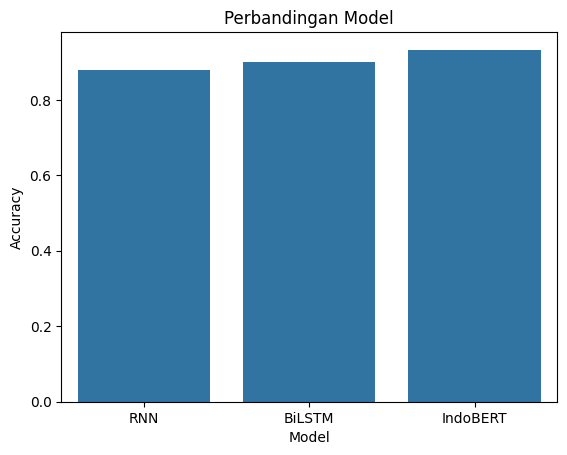

In [25]:
results = pd.DataFrame({
    'Model': ['RNN', 'BiLSTM', 'IndoBERT'],
    'Accuracy': [rnn_acc, bilstm_acc, bert_acc]
})

print(results)

sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Perbandingan Model")
plt.show()

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, model_name, label_names):
    print(f"\n===== {model_name} =====")

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)

    # Precision, Recall, F1 (macro)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return acc, precision, recall, f1
# A small change to ensure re-execution of this function definition cell.


===== RNN =====
Accuracy: 0.8783393501805055
Precision: 0.8775511363886708
Recall: 0.8783393501805055
F1-Score: 0.8776975451251292

Classification Report:
              precision    recall  f1-score   support

      kritik       0.72      0.75      0.73       554
      netral       0.75      0.70      0.72       554
  pertanyaan       0.93      0.94      0.94       554
      pujian       0.99      1.00      1.00       554
       saran       1.00      1.00      1.00       554

    accuracy                           0.88      2770
   macro avg       0.88      0.88      0.88      2770
weighted avg       0.88      0.88      0.88      2770



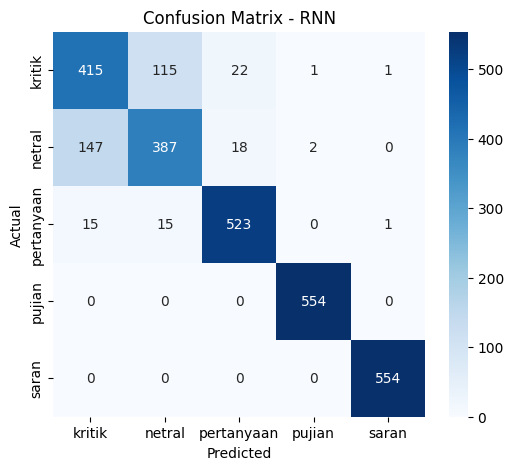

In [27]:
rnn_metrics = evaluate_model(
    y_test,
    rnn_pred,
    "RNN",
    le.classes_
)


===== BiLSTM =====
Accuracy: 0.8996389891696751
Precision: 0.8978544465702886
Recall: 0.8996389891696751
F1-Score: 0.8975624609496299

Classification Report:
              precision    recall  f1-score   support

      kritik       0.85      0.73      0.79       554
      netral       0.78      0.79      0.78       554
  pertanyaan       0.90      0.98      0.94       554
      pujian       0.98      1.00      0.99       554
       saran       0.98      1.00      0.99       554

    accuracy                           0.90      2770
   macro avg       0.90      0.90      0.90      2770
weighted avg       0.90      0.90      0.90      2770



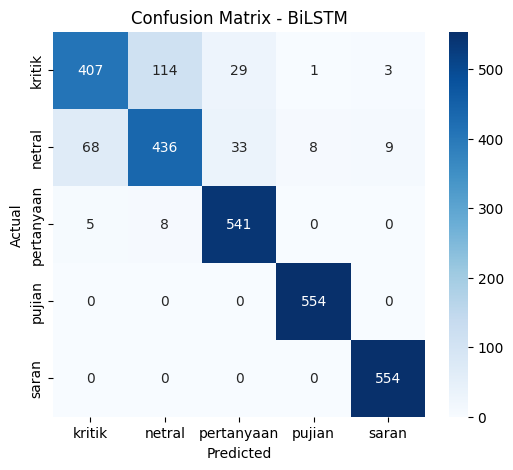

In [28]:
bilstm_metrics = evaluate_model(
    y_test,
    bilstm_pred,
    "BiLSTM",
    le.classes_
)


===== IndoBERT =====
Accuracy: 0.9328519855595668
Precision: 0.9369154775513142
Recall: 0.9328519855595669
F1-Score: 0.9309035597568499

Classification Report:
              precision    recall  f1-score   support

      kritik       0.81      0.94      0.87       554
      netral       0.95      0.73      0.82       554
  pertanyaan       0.97      1.00      0.98       554
      pujian       0.99      1.00      0.99       554
       saran       0.97      1.00      0.98       554

    accuracy                           0.93      2770
   macro avg       0.94      0.93      0.93      2770
weighted avg       0.94      0.93      0.93      2770



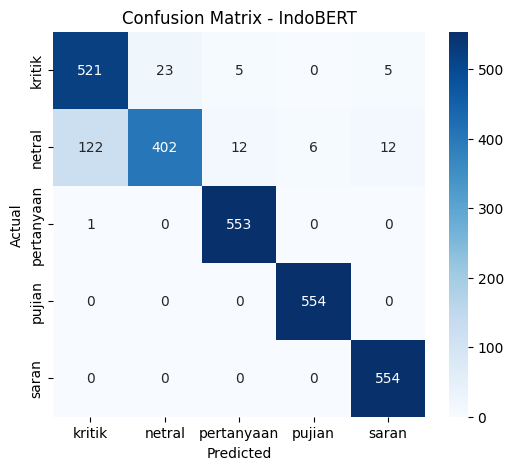

In [29]:
bert_metrics = evaluate_model(
    y_test,
    bert_preds,
    "IndoBERT",
    le.classes_
)

In [30]:
results = pd.DataFrame({
    'Model': ['RNN', 'BiLSTM', 'IndoBERT'],
    'Accuracy': [rnn_metrics[0], bilstm_metrics[0], bert_metrics[0]],
    'Precision': [rnn_metrics[1], bilstm_metrics[1], bert_metrics[1]],
    'Recall': [rnn_metrics[2], bilstm_metrics[2], bert_metrics[2]],
    'F1-Score': [rnn_metrics[3], bilstm_metrics[3], bert_metrics[3]]
})

print(results)

      Model  Accuracy  Precision    Recall  F1-Score
0       RNN  0.878339   0.877551  0.878339  0.877698
1    BiLSTM  0.899639   0.897854  0.899639  0.897562
2  IndoBERT  0.932852   0.936915  0.932852  0.930904


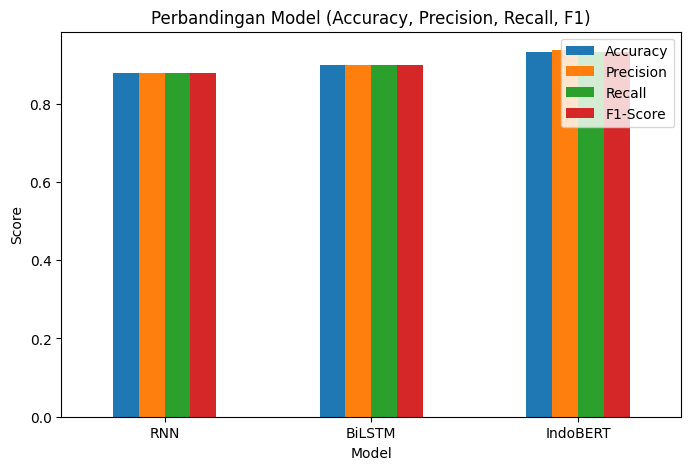

In [31]:
results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.title("Perbandingan Model (Accuracy, Precision, Recall, F1)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()